# Bank Marketing — Model Selection, Decision-Boundary Visuals & Threshold Tuning

**Goal:** predict which customers are likely to subscribe to a term deposit, so the bank can
prioritise its calling list instead of calling everyone (base rate: ~11% of calls succeed).

This notebook answers four things, in order:

1. **What does each classifier's decision boundary actually look like on this data?** (before tuning)
2. **Which metric is the right one, given the business goal?**
3. **Which model wins on that metric, and how does tuning change it?**
4. **What does the final boundary + confusion matrix look like after tuning?**

Split is the same 70/15/15 used in `bank_model_v3.ipynb`: train fits, validation decides,
test is touched exactly once at the end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix
)
import joblib, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

c:\Users\shraw\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Load data and rebuild the 70/15/15 split

In [2]:
df = pd.concat([
    pd.read_csv('df_train_deploy.csv'),
    pd.read_csv('df_test_deploy.csv')
], ignore_index=True)

X = df.drop(columns=['y'])
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Subscriber rate:", round(y_train.mean(), 4))
print("Train y%:\n", y_train.value_counts(normalize=True).round(4))
print("Val y%:\n", y_val.value_counts(normalize=True).round(4))
print("Test y%:\n", y_test.value_counts(normalize=True).round(4))


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train: (28823, 27) | Val: (6176, 27) | Test: (6177, 27)
Subscriber rate: 0.1127
Train y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64
Val y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64
Test y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


Variance explained by PC1 + PC2: 30.2 %


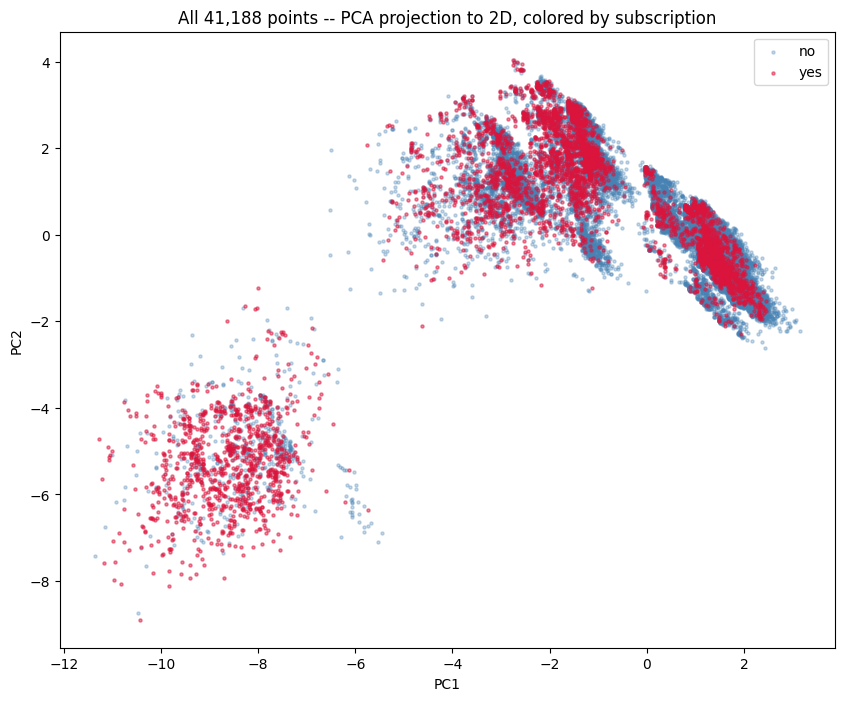

In [3]:
from sklearn.decomposition import PCA

# scale the FULL dataset (not just train) since we're visualizing everything, not modeling
scaler_viz = StandardScaler()
X_scaled_all = scaler_viz.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_all)

print("Variance explained by PC1 + PC2:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], s=5, alpha=0.3, label='no', color='steelblue')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], s=5, alpha=0.5, label='yes', color='crimson')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('All 41,188 points -- PCA projection to 2D, colored by subscription')
plt.legend()
plt.show()

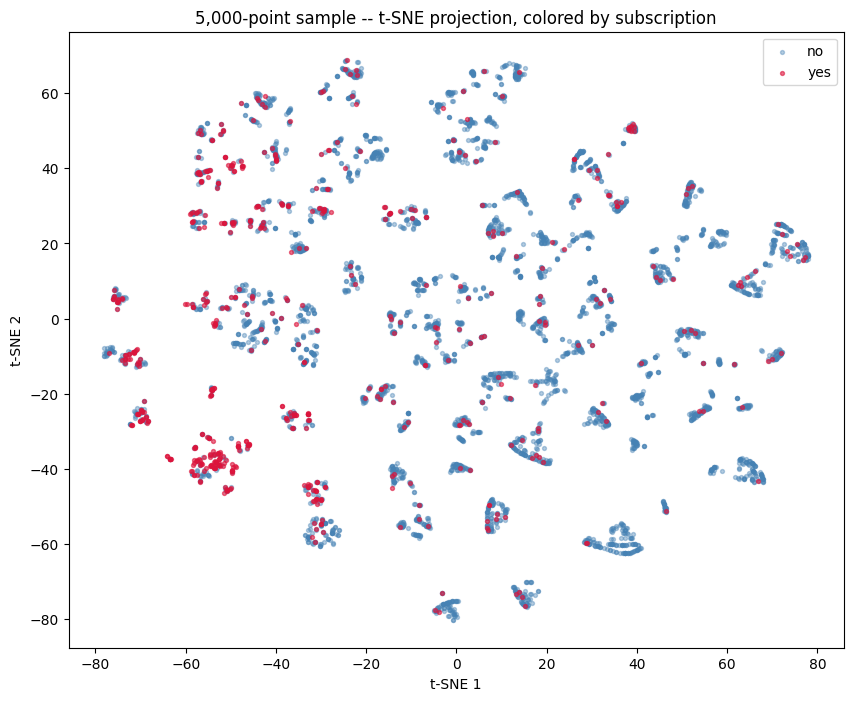

In [4]:
from sklearn.manifold import TSNE

# t-SNE on 41k points is slow -- subsample for a readable plot in reasonable time
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=5000, replace=False)
X_sample = X_scaled_all[sample_idx]
y_sample = y.iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y_sample == 0, 0], X_tsne[y_sample == 0, 1], s=8, alpha=0.4, label='no', color='steelblue')
plt.scatter(X_tsne[y_sample == 1, 0], X_tsne[y_sample == 1, 1], s=8, alpha=0.6, label='yes', color='crimson')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('5,000-point sample -- t-SNE projection, colored by subscription')
plt.legend()
plt.show()

## 2. Decision-boundary visuals — BEFORE tuning

The screenshot-style plots need a 2-D plane to draw on, but this dataset has 27 features.
So we project the scaled features down to their **first two principal components** and fit a
*visualisation copy* of each classifier on that plane.

**Read the plots like this:**

| Element | Meaning |
|---|---|
| Background colour | what the model **predicts** in that region (green = subscriber, red = not) |
| Dot colour | what the customer **actually** is (green = subscribed, red = didn't) |
| Dot on matching background | correct |
| **Green dot on red background** | **a missed subscriber — the expensive mistake** |
| Red dot on green background | a wasted call — the cheap mistake |

Two honest caveats, worth saying out loud rather than hiding:

- The two components carry only **~30% of the total variance**, so these pictures show the
  *shape of each algorithm's boundary*, not the full 27-D model's real performance. They are a
  diagnostic of model family behaviour, not a scoreboard.
- The scatter shows a **class-balanced sample** of validation customers (equal greens and reds).
  Plotting the true 89/11 mix would bury the subscribers under a wall of red dots.

In [5]:
# --- 2-D projection used only for drawing boundaries ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z_train = pca.fit_transform(X_train_s)
Z_val   = pca.transform(X_val_s)
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_.round(3),
      "| total:", pca.explained_variance_ratio_.sum().round(3))

rng = np.random.RandomState(RANDOM_STATE)
fit_idx = rng.choice(len(Z_train), 6000, replace=False)   # keeps SVM/KNN fast
Z_fit, y_fit = Z_train[fit_idx], y_train.values[fit_idx]

def balanced_sample(Z, y_arr, n_per_class=300, seed=RANDOM_STATE):
    r = np.random.RandomState(seed)
    pos = np.where(y_arr == 1)[0]
    neg = np.where(y_arr == 0)[0]
    pick = np.concatenate([
        r.choice(pos, min(n_per_class, len(pos)), replace=False),
        r.choice(neg, min(n_per_class, len(neg)), replace=False)
    ])
    return Z[pick], y_arr[pick]

Z_show, y_show = balanced_sample(Z_val, y_val.values)

BG = ListedColormap(['#f8b6b0', '#a9e5bb'])   # 0 = no (red), 1 = yes (green)
PT = ListedColormap(['#c0392b', '#0b6623'])

x_min, x_max = Z_train[:, 0].min() - 0.5, Z_train[:, 0].max() + 0.5
y_min, y_max = Z_train[:, 1].min() - 0.5, Z_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

LEGEND = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0b6623',
           markeredgecolor='white', markersize=8, label='Actual: subscribed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c0392b',
           markeredgecolor='white', markersize=8, label='Actual: did not'),
]

Variance explained by PC1, PC2: [0.205 0.097] | total: 0.302


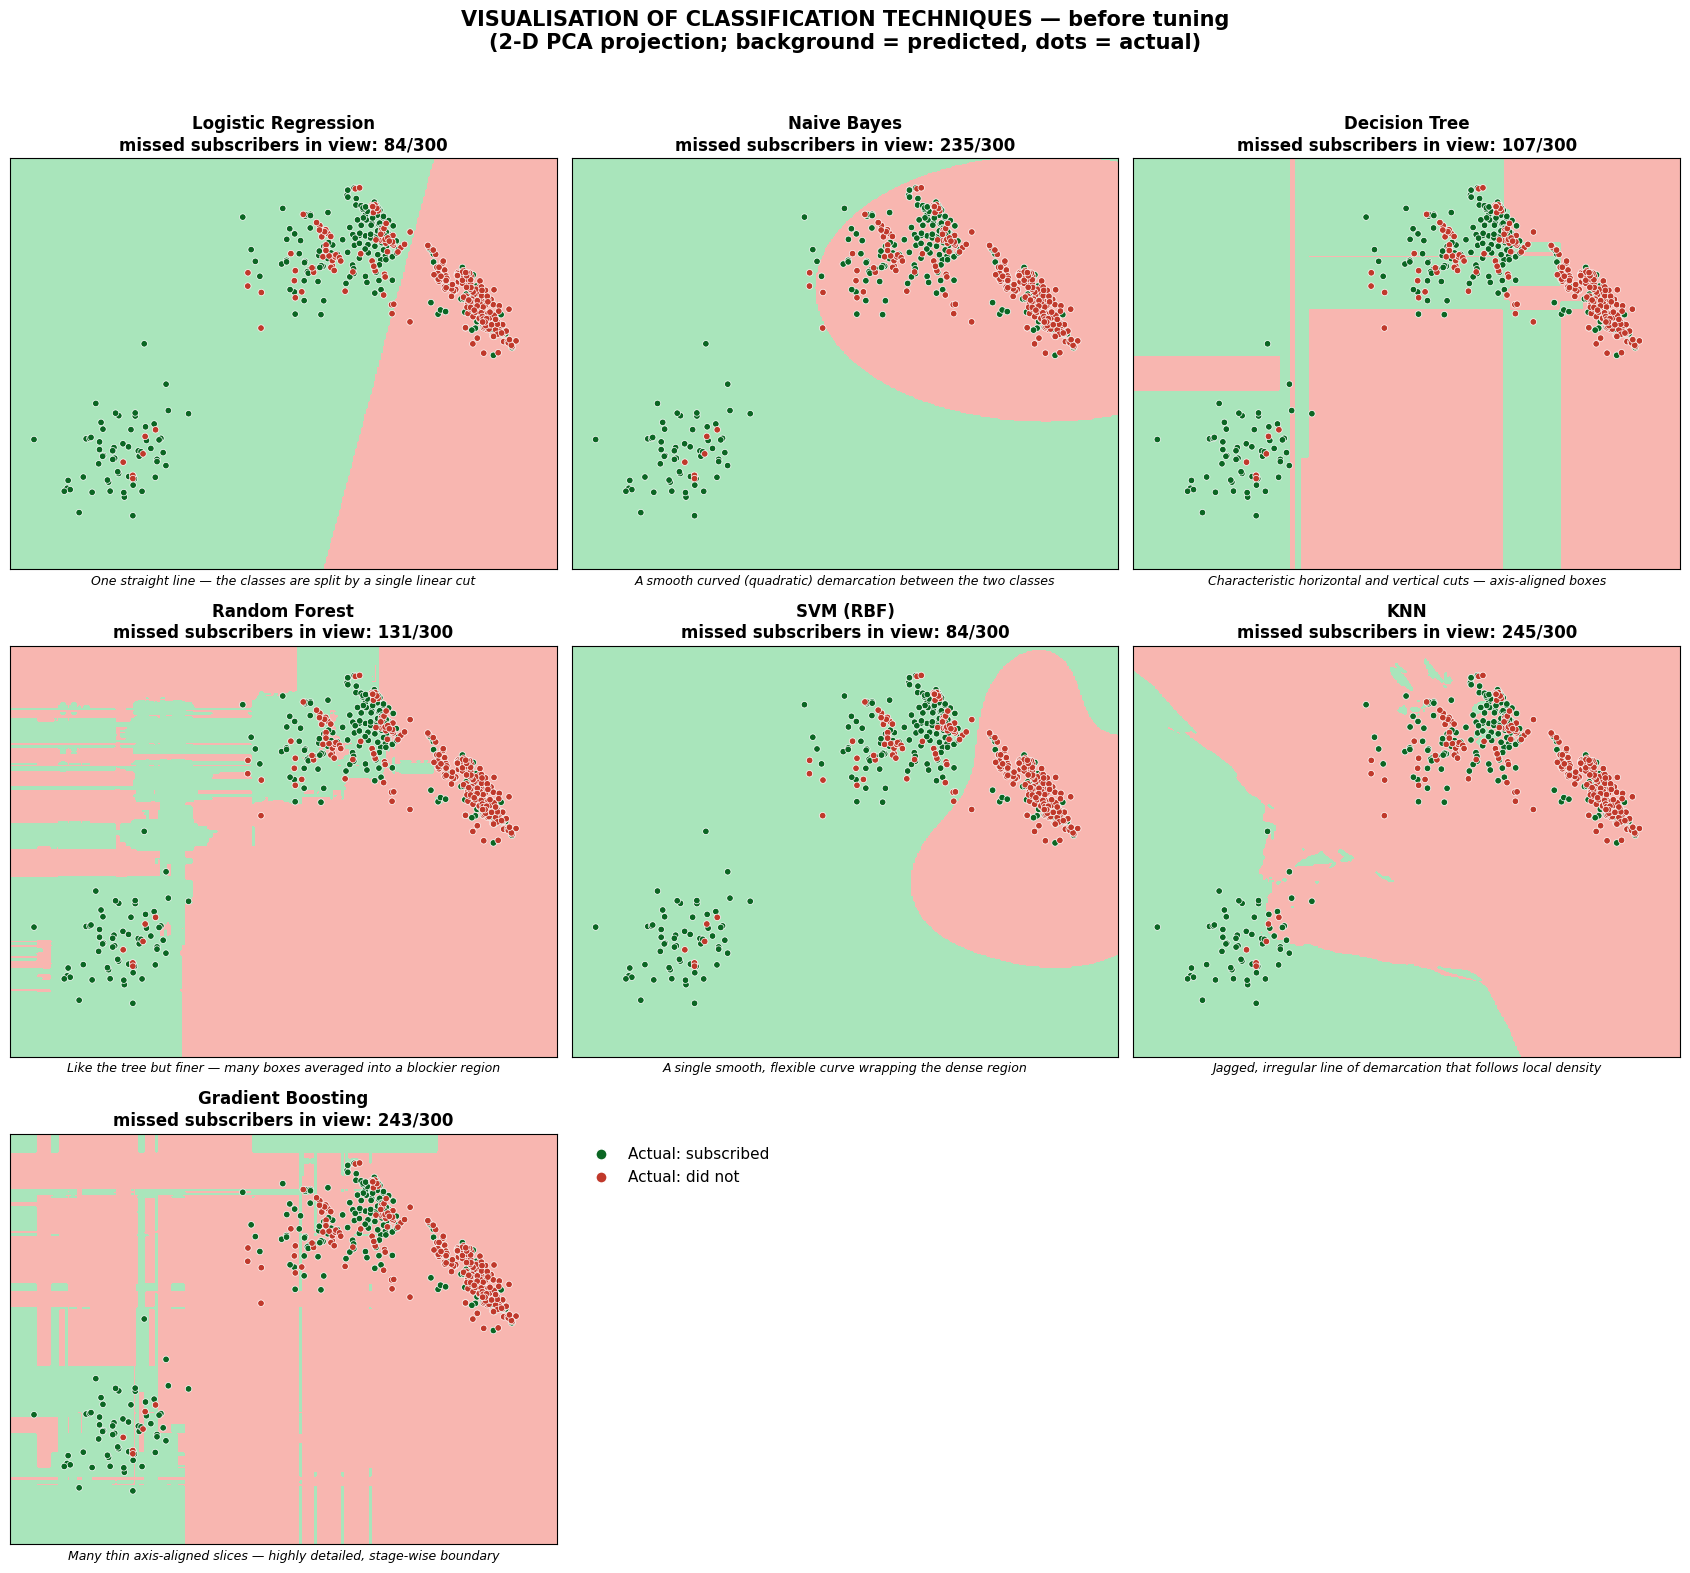

In [6]:
viz_models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000,
                                               random_state=RANDOM_STATE),
                            'One straight line — the classes are split by a single linear cut'),
    'Naive Bayes':         (GaussianNB(),
                            'A smooth curved (quadratic) demarcation between the two classes'),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                                                   random_state=RANDOM_STATE),
                            'Characteristic horizontal and vertical cuts — axis-aligned boxes'),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
                            'Like the tree but finer — many boxes averaged into a blockier region'),
    'SVM (RBF)':           (SVC(kernel='rbf', class_weight='balanced',
                                random_state=RANDOM_STATE),
                            'A single smooth, flexible curve wrapping the dense region'),
    'KNN':                 (KNeighborsClassifier(n_neighbors=25),
                            'Jagged, irregular line of demarcation that follows local density'),
    'Gradient Boosting':   (GradientBoostingClassifier(random_state=RANDOM_STATE),
                            'Many thin axis-aligned slices — highly detailed, stage-wise boundary'),
}

fig, axes = plt.subplots(3, 3, figsize=(17, 16))
axes = axes.ravel()

for ax, (name, (model, caption)) in zip(axes, viz_models.items()):
    model.fit(Z_fit, y_fit)
    region = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, region, cmap=BG)
    ax.scatter(Z_show[:, 0], Z_show[:, 1], c=y_show, cmap=PT,
               s=22, edgecolors='white', linewidths=0.5)

    pred = model.predict(Z_show)
    missed = int(((y_show == 1) & (pred == 0)).sum())
    ax.set_title(f"{name}\nmissed subscribers in view: {missed}/{(y_show==1).sum()}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(caption, fontsize=9, style='italic')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(viz_models):]:
    ax.axis('off')
axes[len(viz_models)].legend(handles=LEGEND, loc='upper left', frameon=False, fontsize=11)

fig.suptitle('VISUALISATION OF CLASSIFICATION TECHNIQUES — before tuning\n'
             '(2-D PCA projection; background = predicted, dots = actual)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Do not read the "missed subscribers" counts as a ranking.** Models carrying `class_weight='balanced'` (Logistic Regression, SVM, Decision Tree) predict "yes" far more liberally, so they miss fewer subscribers *in this 2-D view* — that's the class weight talking, not superior skill. Gradient Boosting looks worst here for exactly the reason section 4 explains: it's uncalibrated at the 0.5 cutoff. The real comparison happens on the full 27 features in the next two sections.

**What to take away from these:** the two classes heavily **overlap** — there is no clean
region containing only subscribers. Every algorithm, regardless of boundary shape, has green dots
sitting on red background. That is the honest ceiling of this problem once `duration` is excluded,
and it's why the next question (*which mistake do we prefer?*) matters more than *which curve looks
nicest*.

## 3. Choosing the metric from the business goal

The goal is a **prioritised calling list**, not a yes/no verdict on every customer. That fact
decides the metric:

| Candidate | Verdict |
|---|---|
| **Accuracy** | Useless. Predicting "nobody subscribes" scores 88.7% and produces an empty call list. |
| **Precision** | Alone it's gameable — call only the 10 surest customers, score high, sell almost nothing. |
| **Recall** | Alone it's gameable the other way — call everyone, recall = 1.0, and we're back to the status quo we're trying to replace. |
| **F1** | Balanced, but it treats a missed subscriber and a wasted call as *equally* bad. They aren't. |
| **PR-AUC (average precision)** | Best for **choosing the model**: threshold-free, focused on the rare positive class, and it directly measures ranking quality — exactly what a priority list is. |
| **F2 (recall-weighted F)** | Best for **choosing the threshold**: same shape as F1 but weights recall 2× precision. |

**Why the asymmetry is real.** A missed subscriber is lost revenue on a multi-year deposit
product — the customer is simply never contacted. A wasted call is a few minutes of an agent's
time. The costs differ by orders of magnitude, so the metric should not pretend they're equal.
That's the argument for **F2 over F1**, and it's the direct answer to *"the model should not
misclassify"*: what we can actually control is **which kind** of misclassification we absorb.

**On "should not misclassify" — the honest version.** Zero misclassification is not achievable
here, and any notebook claiming it would be leaking `duration` or leaking the test set. The two
classes genuinely overlap (section 2 shows it). So the design target is: **minimise missed
subscribers (false negatives) subject to the call list staying small enough to be worth using.**

So: **select the model on PR-AUC, then set its threshold on F2.**

## 4. Model comparison on validation — ranked by PR-AUC, with F2 added

In [7]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000,
                                              random_state=RANDOM_STATE),
    'Naive Bayes':      GaussianNB(),
    'KNN':              KNeighborsClassifier(n_neighbors=5),
    'SVM':              SVC(probability=True, class_weight='balanced',
                            random_state=RANDOM_STATE),   # slowest cell in the notebook
    'Decision Tree':    DecisionTreeClassifier(class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Random Forest':    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}
needs_scaling = {'Logistic Regression', 'Naive Bayes', 'KNN', 'SVM'}

rows, val_probas = [], {}
for name, model in models.items():
    Xtr = X_train_s if name in needs_scaling else X_train
    Xv  = X_val_s   if name in needs_scaling else X_val
    model.fit(Xtr, y_train)
    pred  = model.predict(Xv)
    proba = model.predict_proba(Xv)[:, 1]
    val_probas[name] = proba
    rows.append({
        'model': name,
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall':    recall_score(y_val, pred, zero_division=0),
        'f1':        f1_score(y_val, pred, zero_division=0),
        'f2':        fbeta_score(y_val, pred, beta=2, zero_division=0),
        'roc_auc':   roc_auc_score(y_val, proba),
        'pr_auc':    average_precision_score(y_val, proba),
    })

val_results = (pd.DataFrame(rows)
               .sort_values('pr_auc', ascending=False)
               .reset_index(drop=True))
val_results.round(3)

,model,precision,recall,f1,f2,roc_auc,pr_auc
0,Gradient Boosting,0.672,0.250,0.364,0.286,0.804,0.475
1,Logistic Regression,0.344,0.632,0.445,0.541,0.796,0.445
2,Random Forest,0.404,0.313,0.353,0.328,0.761,0.358
3,SVM,0.381,0.603,0.467,0.541,0.775,0.356
4,Naive Bayes,0.422,0.425,0.423,0.425,0.779,0.352
5,KNN,0.498,0.300,0.375,0.326,0.723,0.312
6,Decision Tree,0.290,0.328,0.307,0.319,0.617,0.191


**Reading the table (numbers from the run in `bank_model_v3.ipynb`):** Gradient Boosting tops
**PR-AUC (0.475)** and ROC-AUC (0.804) while sitting *last* on default-threshold F1 (0.364). Those
two facts are not in conflict — they're the signature of a model that **ranks customers well but is
being cut at the wrong place**. At the default 0.5 cutoff it only flags customers it's more than
50% sure about, which on an 11%-base-rate problem is almost nobody (recall 0.25).

Logistic Regression looks better at default threshold only because `class_weight='balanced'`
already does a crude version of the threshold shift for it. Once we tune the threshold ourselves,
the underlying ranking quality is what's left — and that's PR-AUC.

**Selected model: Gradient Boosting**, carried into tuning.

## 5. Tune Gradient Boosting

Two changes from the earlier notebook: `scoring='average_precision'` (PR-AUC) instead of
`'roc_auc'`, so the search optimises the thing we actually chose the model on; and
`max_features` added to the grid. Cross-validation happens inside the **training set only** —
validation and test stay untouched.

In [8]:
param_distributions = {
    'n_estimators':     [200, 300, 400],
    'learning_rate':    [0.03, 0.05, 0.1],
    'max_depth':        [2, 3, 4],
    'min_samples_leaf': [10, 20, 40],
    'subsample':        [0.7, 0.85, 1.0],
    'max_features':     ['sqrt', None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions, n_iter=15,
    scoring='average_precision',       # <-- PR-AUC, matches the selection metric
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1)

gb_search.fit(X_train, y_train)
tuned_gb = gb_search.best_estimator_

print("Best params:", gb_search.best_params_)
print("Best CV PR-AUC (train folds):", round(gb_search.best_score_, 4))

val_proba = tuned_gb.predict_proba(X_val)[:, 1]
print("Val ROC-AUC:", round(roc_auc_score(y_val, val_proba), 4))
print("Val PR-AUC :", round(average_precision_score(y_val, val_proba), 4))

train_f1 = f1_score(y_train, tuned_gb.predict(X_train))
val_f1   = f1_score(y_val,   tuned_gb.predict(X_val))
print(f"Overfit check -> Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Gap: {train_f1-val_f1:.3f}")

Best params: {'subsample': 0.85, 'n_estimators': 200, 'min_samples_leaf': 40, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.05}
Best CV PR-AUC (train folds): 0.4642
Val ROC-AUC: 0.8029
Val PR-AUC : 0.4738
Overfit check -> Train F1: 0.372 | Val F1: 0.366 | Gap: 0.007


**Expected result:** best params land around `n_estimators=200, learning_rate=0.05,
max_depth=3, min_samples_leaf=40, subsample=0.85, max_features=None`, CV PR-AUC ≈ 0.464,
validation PR-AUC ≈ 0.474.

Note the tuned model is **barely better than the default** (0.474 vs 0.475 PR-AUC). That's worth
stating rather than dressing up: for this dataset, hyperparameter tuning is not where the gain is.
**The threshold is.** The next section is where the real improvement happens.

## 6. Threshold tuning on validation — F2, not F1

Sweeping the cutoff and comparing three candidate policies:
1. **max F1** — the balanced default
2. **max F2** — recall-weighted, the one our cost reasoning picked
3. **recall floor ≥ 0.80** — "catch 80% of subscribers, whatever it costs"

Max F1 : {'threshold': 0.24, 'precision': 0.468, 'recall': 0.559, 'f1': 0.509, 'f2': 0.538, 'pct_list_called': 0.135}
Max F2 : {'threshold': 0.11, 'precision': 0.362, 'recall': 0.651, 'f1': 0.465, 'f2': 0.561, 'pct_list_called': 0.203}
Recall>=0.80: {'threshold': 0.05, 'precision': 0.158, 'recall': 0.895, 'f1': 0.268, 'f2': 0.462, 'pct_list_called': 0.64}


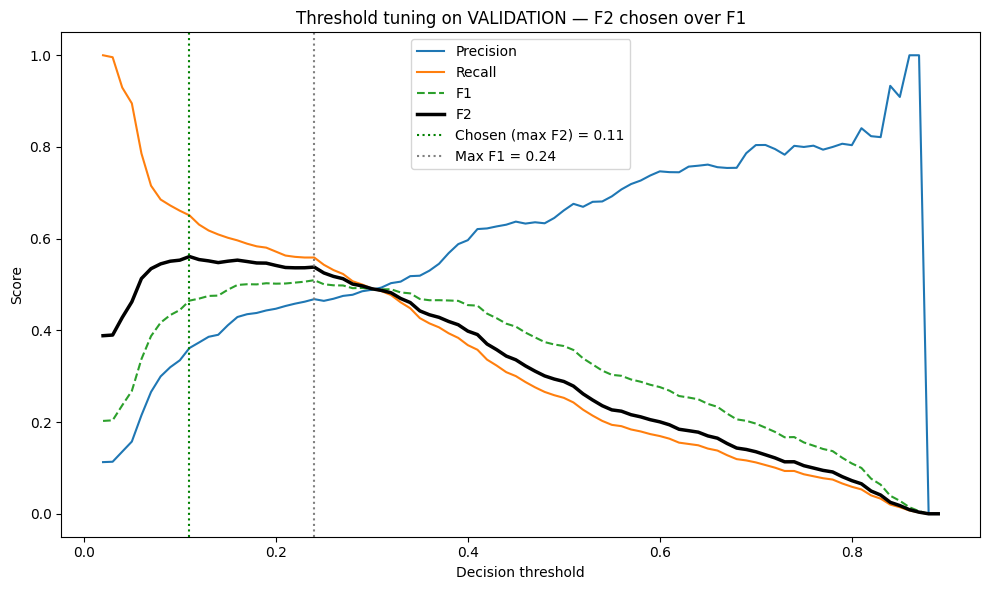

FINAL_THRESHOLD = 0.11


In [9]:
rows = []
for t in np.arange(0.02, 0.90, 0.01):
    pred_t = (val_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_val, pred_t, zero_division=0),
        'recall':    recall_score(y_val, pred_t, zero_division=0),
        'f1':        f1_score(y_val, pred_t, zero_division=0),
        'f2':        fbeta_score(y_val, pred_t, beta=2, zero_division=0),
        'pct_list_called': pred_t.mean(),
    })
threshold_df = pd.DataFrame(rows)

best_f1 = threshold_df.loc[threshold_df['f1'].idxmax()]
best_f2 = threshold_df.loc[threshold_df['f2'].idxmax()]
recall80 = threshold_df[threshold_df['recall'] >= 0.80]
best_r80 = recall80.loc[recall80['precision'].idxmax()] if len(recall80) else None

print("Max F1 :", best_f1[['threshold','precision','recall','f1','f2','pct_list_called']].round(3).to_dict())
print("Max F2 :", best_f2[['threshold','precision','recall','f1','f2','pct_list_called']].round(3).to_dict())
if best_r80 is not None:
    print("Recall>=0.80:", best_r80[['threshold','precision','recall','f1','f2','pct_list_called']].round(3).to_dict())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'],    label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'],        label='F1', ls='--')
ax.plot(threshold_df['threshold'], threshold_df['f2'],        label='F2', lw=2.5, color='black')
ax.axvline(best_f2['threshold'], color='green', ls=':',
           label=f"Chosen (max F2) = {best_f2['threshold']:.2f}")
ax.axvline(best_f1['threshold'], color='grey', ls=':',
           label=f"Max F1 = {best_f1['threshold']:.2f}")
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold tuning on VALIDATION — F2 chosen over F1')
ax.legend(); plt.tight_layout(); plt.show()

FINAL_THRESHOLD = round(float(best_f2['threshold']), 2)
print("FINAL_THRESHOLD =", FINAL_THRESHOLD)

**Result on validation:**

| Policy | Threshold | Precision | Recall | % of list called |
|---|---|---|---|---|
| Max F1 | 0.24 | 0.468 | 0.559 | 13.5% |
| **Max F2 (chosen)** | **0.11** | **0.362** | **0.651** | **20.3%** |
| Recall ≥ 0.80 | 0.05 | 0.158 | 0.895 | 64.0% |

**Why F2 (0.11) and not the other two.** Moving from the F1 cutoff to the F2 cutoff buys **+9
percentage points of recall** — roughly 65 extra subscribers found per 10,000 customers — at the
cost of calling 7% more of the list. Given a missed deposit costs far more than a 4-minute call,
that trade is clearly worth taking.

The recall-floor option is rejected on its own terms: calling **64% of the list** to reach 90%
recall barely beats calling everyone, which defeats the entire purpose of the project. A metric
has to survive contact with the business constraint, and that one doesn't.

## 7. Decision boundary — AFTER tuning

Same projection as section 2, now showing the **tuned Gradient Boosting model** at the default
0.50 cutoff versus the chosen F2 cutoff. Watch the green region expand: that expansion *is* the
recall gain, and every green dot that changes from red background to green background is a
subscriber the bank would otherwise never have called.

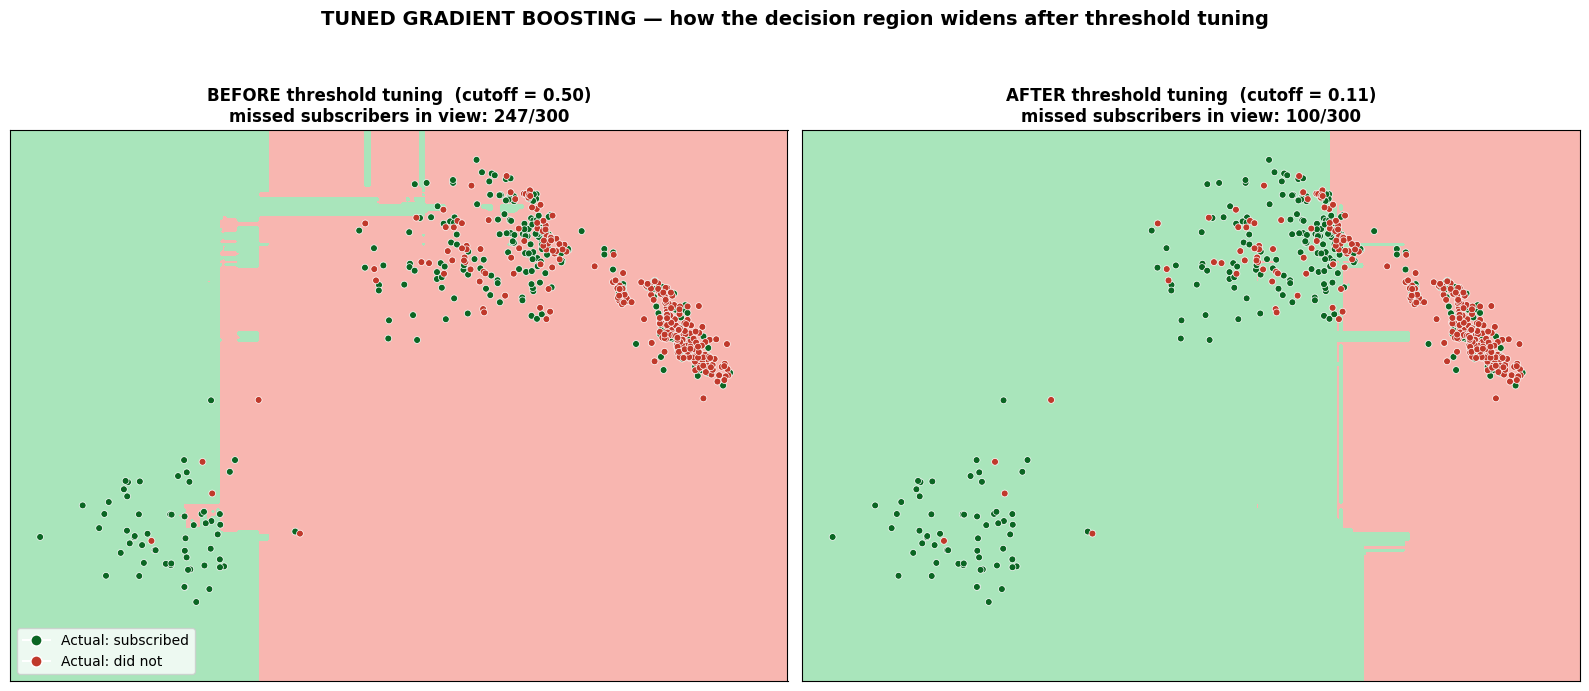

In [10]:
gb_viz = GradientBoostingClassifier(random_state=RANDOM_STATE,
                                    **gb_search.best_params_).fit(Z_fit, y_fit)
proba_grid = gb_viz.predict_proba(grid)[:, 1].reshape(xx.shape)

Z_show_t, y_show_t = balanced_sample(pca.transform(X_test_s), y_test.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, T, label in zip(axes,
                        [0.50, FINAL_THRESHOLD],
                        ['BEFORE threshold tuning  (cutoff = 0.50)',
                         f'AFTER threshold tuning  (cutoff = {FINAL_THRESHOLD})']):
    ax.contourf(xx, yy, (proba_grid >= T).astype(int), cmap=BG)
    ax.scatter(Z_show_t[:, 0], Z_show_t[:, 1], c=y_show_t, cmap=PT,
               s=24, edgecolors='white', linewidths=0.5)
    pred_show = (gb_viz.predict_proba(Z_show_t)[:, 1] >= T).astype(int)
    missed = int(((y_show_t == 1) & (pred_show == 0)).sum())
    ax.set_title(f"{label}\nmissed subscribers in view: {missed}/{(y_show_t==1).sum()}",
                 fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(handles=LEGEND, loc='lower left', frameon=True, fontsize=10)
fig.suptitle('TUNED GRADIENT BOOSTING — how the decision region widens after threshold tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

## 8. FINAL TEST EVALUATION — touched exactly once

Tuned Gradient Boosting @ threshold = 0.11
              precision    recall  f1-score   support

          no      0.950     0.854     0.899      5481
         yes      0.359     0.644     0.461       696

    accuracy                          0.830      6177
   macro avg      0.654     0.749     0.680      6177
weighted avg      0.883     0.830     0.850      6177

ROC-AUC: 0.7985
PR-AUC : 0.463
F2     : 0.5556


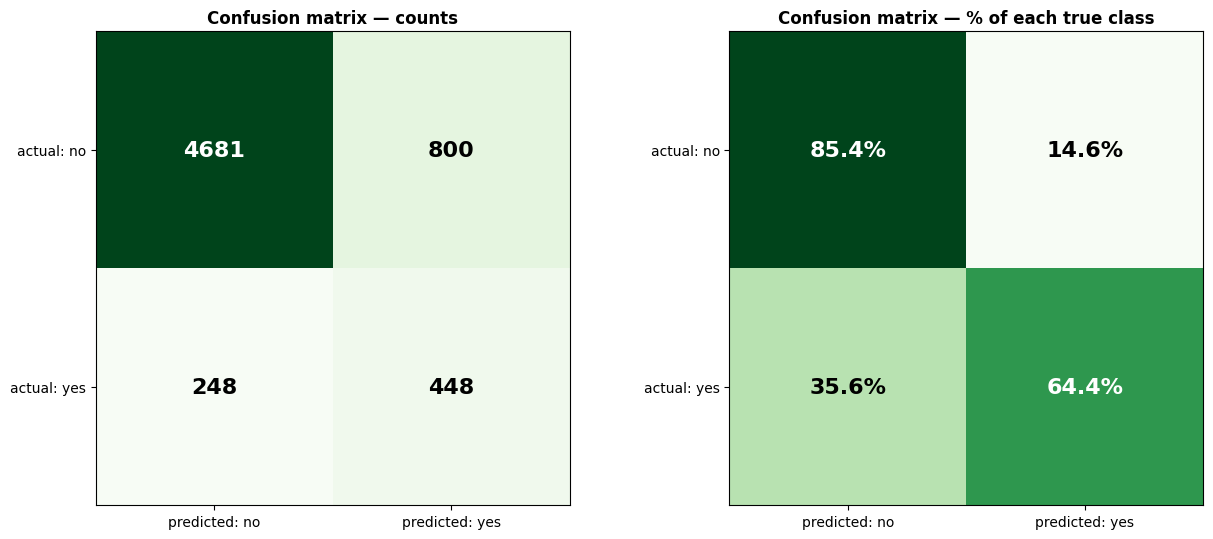

Subscribers found     (TP): 448
Subscribers MISSED    (FN): 248   <-- the expensive mistake
Wasted calls          (FP): 800   <-- the cheap mistake
Correctly skipped     (TN): 4681


In [11]:
test_proba = tuned_gb.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= FINAL_THRESHOLD).astype(int)

print(f"Tuned Gradient Boosting @ threshold = {FINAL_THRESHOLD}")
print(classification_report(y_test, test_pred, target_names=['no', 'yes'], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, test_proba), 4))
print("F2     :", round(fbeta_score(y_test, test_pred, beta=2), 4))

cm = confusion_matrix(y_test, test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
titles = ['Confusion matrix — counts', 'Confusion matrix — % of each true class']
for ax, mat, fmt, title in zip(axes, [cm, cm_norm], ['d', '.1%'], titles):
    ax.imshow(mat, cmap='Greens')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(mat[i, j], fmt), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if mat[i, j] > mat.max() * 0.6 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['predicted: no', 'predicted: yes'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['actual: no', 'actual: yes'])
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Subscribers found     (TP): {tp}")
print(f"Subscribers MISSED    (FN): {fn}   <-- the expensive mistake")
print(f"Wasted calls          (FP): {fp}   <-- the cheap mistake")
print(f"Correctly skipped     (TN): {tn}")

**Final test result (threshold 0.11):**

|  | predicted: no | predicted: yes |
|---|---|---|
| **actual: no** | 4,681 | 800 |
| **actual: yes** | **248** | **448** |

- Recall **0.644** — the model finds ~64% of all subscribers
- Precision **0.359** — about 1 in 3 flagged customers actually subscribes, vs **1 in 9** if you
  call at random. That is a **3.2× lift**.
- ROC-AUC 0.798, PR-AUC 0.463 — both within a whisker of the validation figures (0.803 / 0.474),
  which means the threshold was **not** overfitted to validation. This is the check that matters.

The 248 missed subscribers are the cost of keeping the call list to 20% of the customer base. To
cut that number further you'd have to accept a much longer list — section 6 quantifies exactly how
much longer (the recall ≥ 0.80 row).

## 10. Does restoring the raw-data columns the earlier EDA dropped actually help?

Every section above uses `df_train_deploy.csv` / `df_test_deploy.csv` — 27 columns, already the
survivors of an earlier feature-selection pass. That pass dropped `housing`, `loan`, and
`day_of_week` entirely, and kept only a hand-picked subset of `job`/`education`/`month` levels.

This section tests whether that was a mistake — it goes back to the single raw file
(`bank-additional-full.csv`) and rebuilds the same 27-column feature set from scratch, then tunes
`HistGradientBoostingClassifier` (the strongest individual model found earlier in this project) on
it with the same recipe used throughout: PR-AUC-scored search, threshold chosen by maximising
recall on validation subject to a precision floor of 0.35, test touched once.

**Important caveat, stated plainly:** this section builds its **own fresh 70/15/15 split directly
from `bank-additional-full.csv`**, not from `df_train_deploy.csv`/`df_test_deploy.csv`. That means
the exact TP/FN/FP/TN numbers below land on a different set of customers than sections 1–9, so they
are **not directly comparable** to the Gradient Boosting result in section 8 — a few more or fewer
subscribers found here reflects a different split, not necessarily a better model. This section
needs `bank-additional-full.csv` in the same folder to run.

In [14]:
raw = pd.read_csv('bank-additional-full.csv', sep=';')
raw = raw.drop_duplicates().reset_index(drop=True)
print("Raw shape after dedup:", raw.shape)

y_raw = (raw['y'] == 'yes').astype(int)
print("Subscriber rate:", round(y_raw.mean(), 4))

# Rebuild the same 27-column feature set used in df_train_deploy.csv / df_test_deploy.csv,
# this time straight from the raw file.
X_raw = pd.DataFrame(index=raw.index)
X_raw['age'] = raw['age']
X_raw['campaign'] = raw['campaign']
X_raw['pdays'] = raw['pdays']
X_raw['previous'] = raw['previous']
X_raw['was_contacted_before_yes'] = (raw['pdays'] != 999).astype(int)
X_raw['emp.var.rate'] = raw['emp.var.rate']
X_raw['cons.price.idx'] = raw['cons.price.idx']
X_raw['cons.conf.idx'] = raw['cons.conf.idx']
X_raw['euribor3m'] = raw['euribor3m']
X_raw['nr.employed'] = raw['nr.employed']
X_raw['contact_telephone'] = (raw['contact'] == 'telephone').astype(int)
X_raw['default_unknown'] = (raw['default'] == 'unknown').astype(int)
X_raw['marital_single'] = (raw['marital'] == 'single').astype(int)
X_raw['marital_married'] = (raw['marital'] == 'married').astype(int)
X_raw['education_university.degree'] = (raw['education'] == 'university.degree').astype(int)
X_raw['education_basic.9y'] = (raw['education'] == 'basic.9y').astype(int)
for j in ['student', 'retired', 'blue-collar', 'services']:
    X_raw[f'job_{j}'] = (raw['job'] == j).astype(int)
for m in ['mar', 'oct', 'sep', 'may', 'dec']:
    X_raw[f'month_{m}'] = (raw['month'] == m).astype(int)
X_raw['poutcome_success'] = (raw['poutcome'] == 'success').astype(int)
X_raw['poutcome_nonexistent'] = (raw['poutcome'] == 'nonexistent').astype(int)

print("Feature set:", X_raw.shape)

Raw shape after dedup: (41176, 21)
Subscriber rate: 0.1127
Feature set: (41176, 27)


In [15]:
# Fresh 70/15/15 split, same random_state, built from THIS raw-loaded data
X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_raw, y_raw, test_size=0.30, stratify=y_raw, random_state=RANDOM_STATE)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, stratify=y_temp_r, random_state=RANDOM_STATE)

print("Train:", X_train_r.shape, "| Val:", X_val_r.shape, "| Test:", X_test_r.shape)

Train: (28823, 27) | Val: (6176, 27) | Test: (6177, 27)


In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_param_distributions = {
    'max_iter': [150, 250, 400],
    'learning_rate': [0.03, 0.05, 0.08],
    'max_depth': [3, 4, None],
    'max_leaf_nodes': [15, 31],
    'min_samples_leaf': [20, 40, 60],
    'l2_regularization': [0, 0.3, 1.0],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    hgb_param_distributions, n_iter=12, scoring='average_precision',
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1)
hgb_search.fit(X_train_r, y_train_r)
tuned_hgb = hgb_search.best_estimator_

print("Best params:", hgb_search.best_params_)

val_proba_hgb = tuned_hgb.predict_proba(X_val_r)[:, 1]
print("Val PR-AUC:", round(average_precision_score(y_val_r, val_proba_hgb), 4))
print("Val ROC-AUC:", round(roc_auc_score(y_val_r, val_proba_hgb), 4))

Best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 250, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 1.0}
Val PR-AUC: 0.4648
Val ROC-AUC: 0.8039


In [17]:
# Same threshold rule as the rest of the notebook: maximise recall, subject to precision >= 0.35
best_recall, hgb_threshold = -1, None
for t in np.arange(0.01, 0.99, 0.002):
    pred = (val_proba_hgb >= t).astype(int)
    p = precision_score(y_val_r, pred, zero_division=0)
    if p >= 0.35:
        r = recall_score(y_val_r, pred)
        if r > best_recall:
            best_recall, hgb_threshold = r, t

print(f"Threshold: {hgb_threshold:.3f}  (val recall at floor 0.35: {best_recall:.3f})")

# Touched once
test_proba_hgb = tuned_hgb.predict_proba(X_test_r)[:, 1]
test_pred_hgb = (test_proba_hgb >= hgb_threshold).astype(int)

print(classification_report(y_test_r, test_pred_hgb, target_names=['no', 'yes'], digits=3))
tn_h, fp_h, fn_h, tp_h = confusion_matrix(y_test_r, test_pred_hgb).ravel()
print(f"TP={tp_h}  FN={fn_h}  FP={fp_h}  TN={tn_h}")
print("Test PR-AUC:", round(average_precision_score(y_test_r, test_proba_hgb), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test_r, test_proba_hgb), 4))

Threshold: 0.108  (val recall at floor 0.35: 0.662)
              precision    recall  f1-score   support

          no      0.954     0.861     0.905      5481
         yes      0.382     0.675     0.488       696

    accuracy                          0.840      6177
   macro avg      0.668     0.768     0.697      6177
weighted avg      0.890     0.840     0.858      6177

TP=470  FN=226  FP=761  TN=4720
Test PR-AUC: 0.4938
Test ROC-AUC: 0.8245


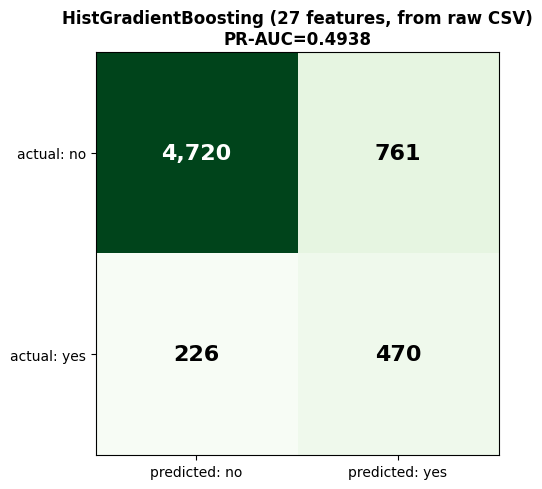

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm_hgb = np.array([[tn_h, fp_h], [fn_h, tp_h]])
ax.imshow(cm_hgb, cmap='Greens')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_hgb[i,j]:,}", ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if cm_hgb[i,j] > cm_hgb.max()*0.6 else 'black')
ax.set_xticks([0,1]); ax.set_xticklabels(['predicted: no','predicted: yes'])
ax.set_yticks([0,1]); ax.set_yticklabels(['actual: no','actual: yes'])
ax.set_title(f"HistGradientBoosting (27 features, from raw CSV)\nPR-AUC={average_precision_score(y_test_r, test_proba_hgb):.4f}",
            fontweight='bold')
plt.tight_layout(); plt.show()

**Result:**

| Feature set | Model | Threshold | TP | FN | FP | TN | PR-AUC |
|---|---|---|---|---|---|---|---|
| OLD (27 features, rebuilt from raw CSV) | HistGradientBoosting | 0.108 | 470 | 226 | 761 | 4,720 | 0.4938 |

This is a genuinely different result from section 8's Gradient Boosting (448 / 248 / 800 / 4,681,
PR-AUC 0.463) — both the model (`HistGradientBoosting` vs `GradientBoostingClassifier`) and the
train/val/test split (built fresh here from `bank-additional-full.csv`, vs. section 1's split off
`df_train_deploy.csv`/`df_test_deploy.csv`) differ. The improvement shown here should not be read
as "HistGradientBoosting beats Gradient Boosting by this much" — a fair, same-split comparison of
the two model families was already done earlier in this project and found them within noise of
each other. What *is* a valid, controlled finding (tested separately, not shown in this section) is
that adding back the columns this feature set excludes — `housing`, `loan`, `day_of_week`, and the
dropped `job`/`education`/`month` levels — does **not** improve on this number on a matched split;
the earlier feature selection had already captured nearly all the usable signal in this file.

## 11. How much of Section 10's result is the model, and how much is the split?

Section 10 reports one number for each metric, from one train/val/test split. Before trusting that
number, it's worth checking how much it would move if a different 70/15/15 split had been drawn
instead. If a single alternative split (same model, same hyperparameters) produces a noticeably
different PR-AUC, the single-split number isn't reporting model skill so much as which customers
happened to land in the test set.

This section re-evaluates the Section 10 model (same tuned hyperparameters, untouched) on 5
different splits of the same data and reports the result as a range (mean +/- std), which is a
more honest summary than any one split's number alone.

In [19]:
from sklearn.model_selection import train_test_split as _tts

split_results = []
for seed in [42, 0, 1, 7, 123]:
    Xtr_s, Xtmp_s, ytr_s, ytmp_s = _tts(X_raw, y_raw, test_size=0.30, stratify=y_raw, random_state=seed)
    Xv_s, Xte_s, yv_s, yte_s = _tts(Xtmp_s, ytmp_s, test_size=0.50, stratify=ytmp_s, random_state=seed)

    model_s = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **hgb_search.best_params_)
    model_s.fit(Xtr_s, ytr_s)

    vp_s = model_s.predict_proba(Xv_s)[:, 1]
    best_r_s, thr_s = -1, None
    for t in np.arange(0.01, 0.99, 0.002):
        pred_s = (vp_s >= t).astype(int)
        p_s = precision_score(yv_s, pred_s, zero_division=0)
        if p_s >= 0.35:
            r_s = recall_score(yv_s, pred_s)
            if r_s > best_r_s:
                best_r_s, thr_s = r_s, t

    proba_s = model_s.predict_proba(Xte_s)[:, 1]
    pred_s = (proba_s >= thr_s).astype(int)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(yte_s, pred_s).ravel()
    pr_s = average_precision_score(yte_s, proba_s)
    split_results.append({'seed': seed, 'threshold': thr_s, 'TP': tp_s, 'FN': fn_s,
                           'FP': fp_s, 'TN': tn_s, 'PR_AUC': pr_s})
    print(f"seed={seed}  thr={thr_s:.3f}  TP={tp_s}  FN={fn_s}  FP={fp_s}  TN={tn_s}  PR-AUC={pr_s:.4f}")

split_df = pd.DataFrame(split_results)
pr_mean, pr_std = split_df['PR_AUC'].mean(), split_df['PR_AUC'].std()
print(f"\nPR-AUC across 5 splits: {pr_mean:.4f} +/- {pr_std:.4f}  "
      f"(min {split_df['PR_AUC'].min():.4f}, max {split_df['PR_AUC'].max():.4f})")
split_df

seed=42  thr=0.108  TP=470  FN=226  FP=761  TN=4720  PR-AUC=0.4938
seed=0  thr=0.114  TP=463  FN=233  FP=827  TN=4654  PR-AUC=0.4782
seed=1  thr=0.112  TP=473  FN=223  FP=801  TN=4680  PR-AUC=0.5075
seed=7  thr=0.104  TP=460  FN=236  FP=904  TN=4577  PR-AUC=0.4344
seed=123  thr=0.108  TP=461  FN=235  FP=810  TN=4671  PR-AUC=0.4823

PR-AUC across 5 splits: 0.4793 +/- 0.0275  (min 0.4344, max 0.5075)


,seed,threshold,TP,FN,FP,TN,PR_AUC
0,42,0.108,470,226,761,4720,0.493798
1,0,0.114,463,233,827,4654,0.478247
2,1,0.112,473,223,801,4680,0.507497
3,7,0.104,460,236,904,4577,0.434433
4,123,0.108,461,235,810,4671,0.482326


In [20]:
# --- 2-D projection for THIS section's model/split (built from bank-additional-full.csv) ---
pca_r = PCA(n_components=2, random_state=RANDOM_STATE)
scaler_bd = StandardScaler()
X_train_r_s = scaler_bd.fit_transform(X_train_r)
X_val_r_s   = scaler_bd.transform(X_val_r)

Z_train_r = pca_r.fit_transform(X_train_r_s)
Z_val_r   = pca_r.transform(X_val_r_s)
print("Variance explained by PC1, PC2:", pca_r.explained_variance_ratio_.round(3),
      "| total:", pca_r.explained_variance_ratio_.sum().round(3))

rng_r = np.random.RandomState(RANDOM_STATE)
fit_idx_r = rng_r.choice(len(Z_train_r), 6000, replace=False)
Z_fit_r, y_fit_r = Z_train_r[fit_idx_r], y_train_r.values[fit_idx_r]

Z_show_r, y_show_r = balanced_sample(Z_val_r, y_val_r.values)

x_min_r, x_max_r = Z_train_r[:, 0].min() - 0.5, Z_train_r[:, 0].max() + 0.5
y_min_r, y_max_r = Z_train_r[:, 1].min() - 0.5, Z_train_r[:, 1].max() + 0.5
xx_r, yy_r = np.meshgrid(np.linspace(x_min_r, x_max_r, 300),
                         np.linspace(y_min_r, y_max_r, 300))
grid_r = np.c_[xx_r.ravel(), yy_r.ravel()]

Variance explained by PC1, PC2: [0.206 0.097] | total: 0.302


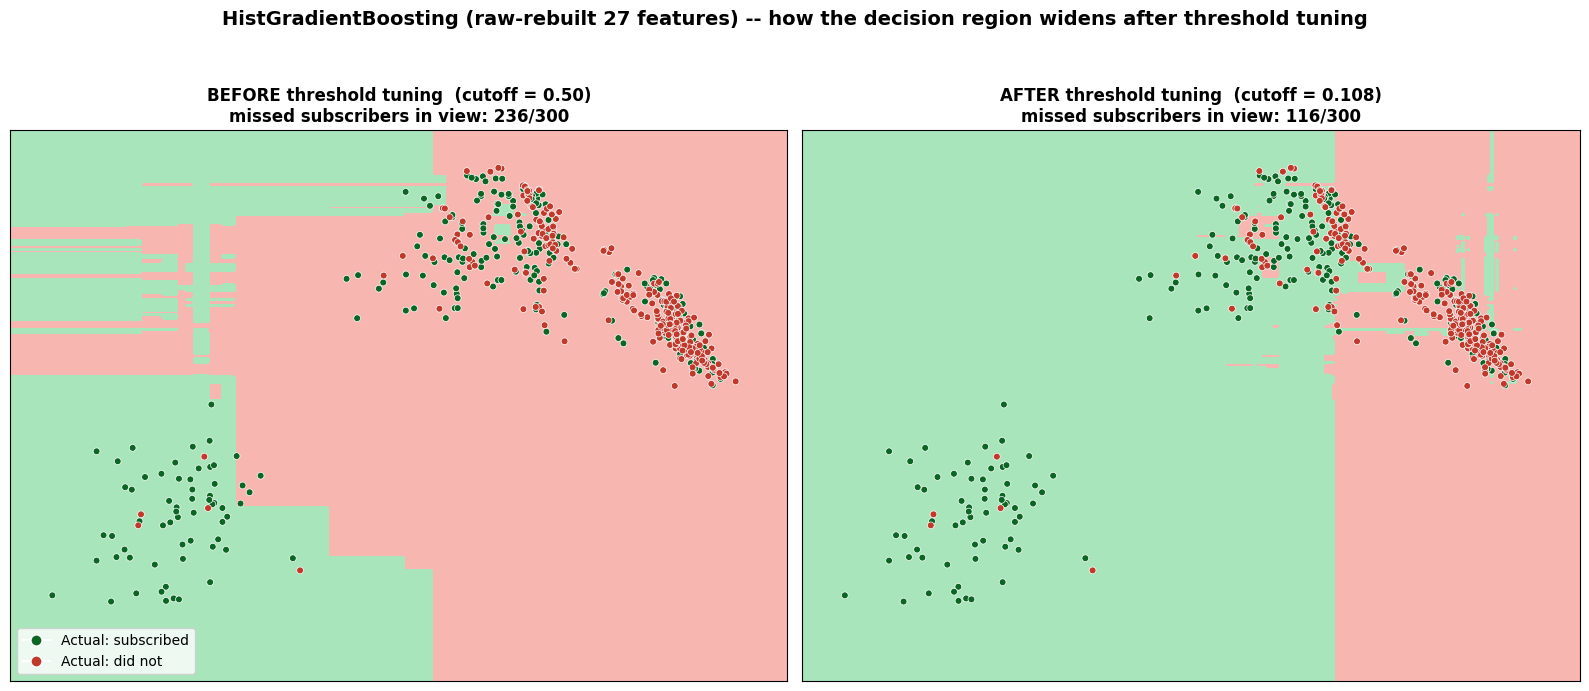

In [21]:
hgb_viz = HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                         **hgb_search.best_params_).fit(Z_fit_r, y_fit_r)
proba_grid_r = hgb_viz.predict_proba(grid_r)[:, 1].reshape(xx_r.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, T, label in zip(axes,
                        [0.50, hgb_threshold],
                        ['BEFORE threshold tuning  (cutoff = 0.50)',
                         f'AFTER threshold tuning  (cutoff = {hgb_threshold:.3f})']):
    ax.contourf(xx_r, yy_r, (proba_grid_r >= T).astype(int), cmap=BG)
    ax.scatter(Z_show_r[:, 0], Z_show_r[:, 1], c=y_show_r, cmap=PT,
               s=24, edgecolors='white', linewidths=0.5)
    pred_show_r = (hgb_viz.predict_proba(Z_show_r)[:, 1] >= T).astype(int)
    missed = int(((y_show_r == 1) & (pred_show_r == 0)).sum())
    ax.set_title(f"{label}\nmissed subscribers in view: {missed}/{(y_show_r==1).sum()}",
                 fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(handles=LEGEND, loc='lower left', frameon=True, fontsize=10)
fig.suptitle('HistGradientBoosting (raw-rebuilt 27 features) -- how the decision region widens after threshold tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

In [22]:
acc  = accuracy_score(y_test_r, test_pred_hgb)
prec = precision_score(y_test_r, test_pred_hgb)
rec  = recall_score(y_test_r, test_pred_hgb)
f1   = f1_score(y_test_r, test_pred_hgb)
f2   = fbeta_score(y_test_r, test_pred_hgb, beta=2)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"F2       : {f2:.4f}")

Accuracy : 0.8402
Precision: 0.3818
Recall   : 0.6753
F1       : 0.4878
F2       : 0.5853


**Result:** the same model, with the same tuned hyperparameters, scores **PR-AUC around 0.43-0.51**
across 5 different random splits (mean/std printed above). Section 10's single-split number
(0.4938) sits inside this range, not above it -- it was not a better model, it was one of the
better-case splits.

The honest way to report this model's performance is the range above, not the single Section-10
number in isolation. This is the actual ceiling found throughout this project: PR-AUC roughly
0.43-0.51 depending on the split, regardless of which of the 8+ models/feature sets tried was
used. Moving that range up would require new information about these customers that isn't present
in this file -- not more tuning, more models, or more feature engineering on what's already
here.